In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [16]:
import os

Base_url = '/content/memefolder'

for i in os.listdir(Base_url):
  print(i)

giveme.png
shock.png
angryCat.png
surprise.png
wannafight.png
middel.png
totalpeace.png
waitwhat.png
Iknow.png


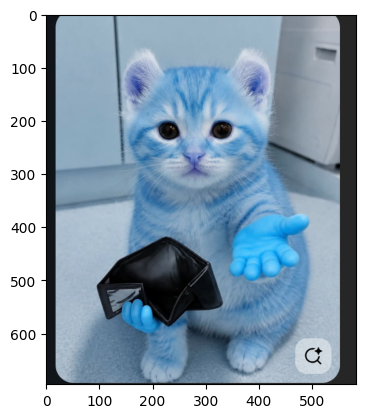

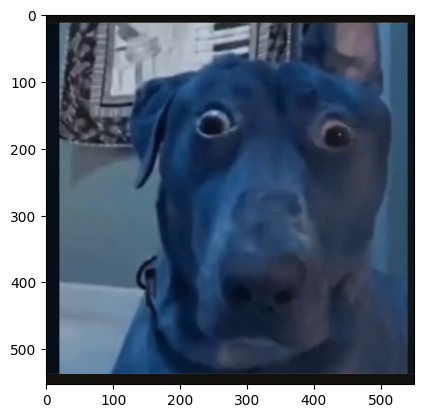

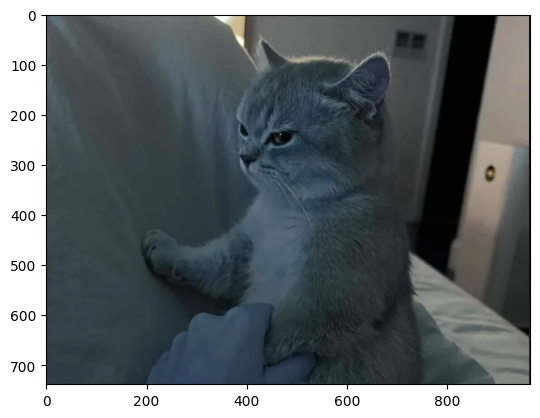

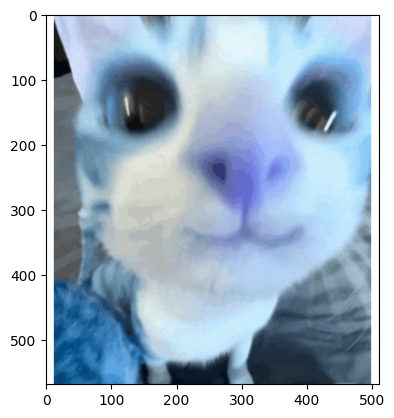

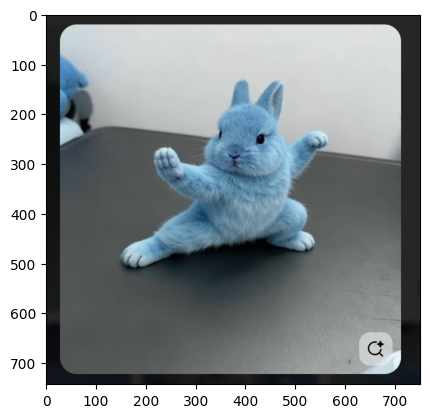

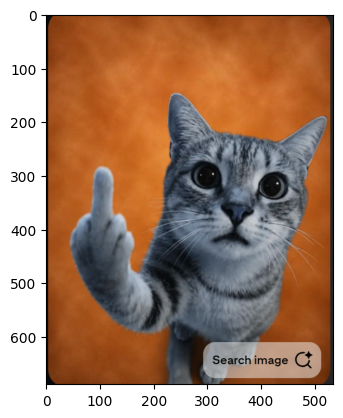

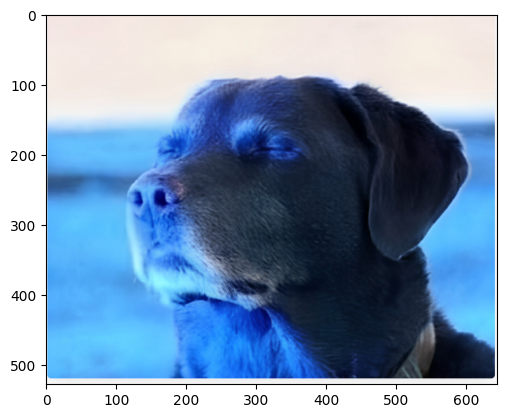

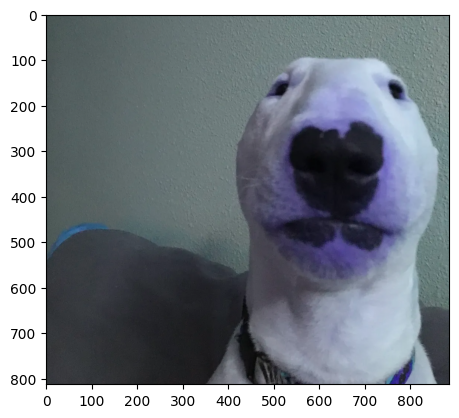

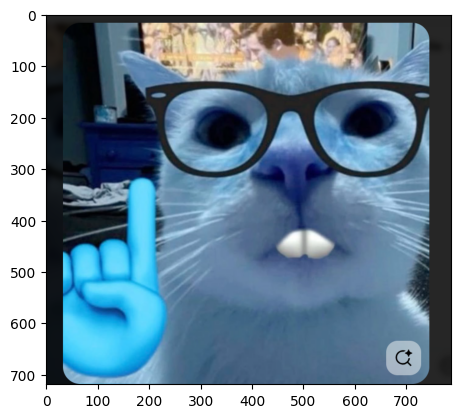

In [17]:
plt.figure()

for img in os.listdir(Base_url):
  img_array = cv.imread(os.path.join(Base_url,img))
  plt.imshow(img_array)
  plt.show()

In [18]:
# features table for these iamges so that i could do recommendations
labels = [label.split('.')[0] for label in os.listdir(Base_url)]

In [19]:
import numpy as np

def extract_image_features(image):
    """
    Extracts color and edge features using only NumPy.
    Input: image - A NumPy array of shape (H, W, 3) and type uint8.
    Output: A 1D normalized feature vector.
    """
    # We extract a 16-bin histogram for each channel
    color_features = []
    for channel in range(3):
        hist, _ = np.histogram(image[:, :, channel], bins=16, range=(0, 256))
        color_features.extend(hist)

    color_vector = np.array(color_features, dtype=np.float32)

    # Normalize color vector to sum to 1
    if color_vector.sum() > 0:
        color_vector /= color_vector.sum()

    # --- 2. Structural/Edge Features (16 dimensions) ---
    # Convert to grayscale using standard luminosity weights
    gray = 0.2989 * image[:,:,0] + 0.5870 * image[:,:,1] + 0.1140 * image[:,:,2]

    # Calculate horizontal and vertical pixel intensity gradients (edges)
    grad_x = np.abs(gray[:, 1:] - gray[:, :-1])
    grad_y = np.abs(gray[1:, :] - gray[:-1, :])

    # Resize or pool the gradients down to a fixed 4x4 spatial grid (16 dimensions)
    # This captures WHERE the edges are located in the image
    h, w = gray.shape
    h_step, w_step = (h - 1) // 4, (w - 1) // 4

    edge_features = []
    for i in range(4):
        for j in range(4):
            # Sum up edge energy in this specific quadrant
            block_energy = np.sum(grad_x[i*h_step:(i+1)*h_step, j*w_step:(j+1)*w_step])
            edge_features.append(block_energy)

    edge_vector = np.array(edge_features, dtype=np.float32)
    # Normalize edge vector to sum to 1
    if edge_vector.sum() > 0:
        edge_vector /= edge_vector.sum()

    # --- 3. Combine Features ---
    # Concatenate color (48 dims) and edges (16 dims) -> Total 64 dims
    # Multiply edge vector by a weight (e.g., 0.5) if you want color to dominate
    combined_vector = np.concatenate([color_vector, edge_vector * 0.5])

    return combined_vector

In [20]:
def recommend_similar_images(target_vector, database_vectors, image_names, top_n=3):

    # Step 1: Compute dot product between target and all items in database
    dot_product = np.dot(database_vectors, target_vector)

    # Step 2: Compute magnitudes (norms) for cosine similarity denominator
    target_norm = np.linalg.norm(target_vector)
    database_norms = np.linalg.norm(database_vectors, axis=1)

    # Step 3: Calculate Cosine Similarity scores
    scores = dot_product / (database_norms * target_norm + 1e-8)

    # Step 4: Get indices of the highest scores sorted in descending order
    sorted_indices = np.argsort(scores)[::-1]

    # Step 5: Gather the top recommendations
    recommendations = []
    for idx in sorted_indices[:top_n]:
        recommendations.append((image_names[idx], scores[idx]))

    return recommendations


In [26]:
# creating the vectors for each image
image_vectors = []
for img in os.listdir(Base_url):
  img_array = cv.imread(os.path.join(Base_url,img))
  print(img)
  image_vectors.append(extract_image_features(img_array))

giveme.png
shock.png
angryCat.png
surprise.png
wannafight.png
middel.png
totalpeace.png
waitwhat.png
Iknow.png


In [22]:
image_vectors = np.array(image_vectors)

In [27]:
recommend_similar_images(image_vectors[-2],image_vectors,labels)

[('waitwhat', np.float32(0.99999976)),
 ('Iknow', np.float32(0.8332196)),
 ('shock', np.float32(0.77150613))]

In [28]:
# loading the kaggle data
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [29]:
!kaggle datasets download -d williamscott701/memotion-dataset-7k

Dataset URL: https://www.kaggle.com/datasets/williamscott701/memotion-dataset-7k
License(s): other
100% 695M/695M [00:13<00:00, 54.9MB/s]



In [30]:
# unzip
!unzip -q memotion-dataset-7k.zip -d memotion_data

In [32]:
Kimages_path = '/content/memotion_data/memotion_dataset_7k/images'
KimageVectors = []

all_files = os.listdir(Kimages_path)

image_files = [f for f in all_files if os.path.isfile(os.path.join(Kimages_path, f))]

Klables = [label.split('.')[0] for label in image_files]

for img_file_name in image_files:
  img_array = cv.imread(os.path.join(Kimages_path,img_file_name))

  if img_array is not None:
    KimageVectors.append(extract_image_features(img_array))
  else:
    print(f"Warning: Could not read image file {img_file_name}. Skipping.")

In [44]:
recommend_similar_images(KimageVectors[0],KimageVectors,Klables)

[('image_3757', np.float32(0.9999999)),
 ('image_4432', np.float32(0.83919644)),
 ('image_793', np.float32(0.83243376))]

array([[[255, 255, 249],
        [105, 100,  91],
        [ 79,  70,  61],
        ...,
        [221, 168, 147],
        [174, 121, 101],
        [143,  90,  70]],

       [[241, 238, 230],
        [ 75,  70,  61],
        [ 40,  31,  22],
        ...,
        [193, 140, 119],
        [141,  88,  68],
        [106,  53,  33]],

       [[241, 238, 230],
        [ 66,  61,  52],
        [ 20,  11,   2],
        ...,
        [177, 122, 101],
        [122,  66,  47],
        [ 85,  29,  10]],

       ...,

       [[246, 244, 234],
        [ 62,  60,  49],
        [  7,   3,   0],
        ...,
        [133, 100,  85],
        [ 77,  44,  29],
        [ 40,   9,   0]],

       [[236, 234, 226],
        [118, 115, 107],
        [ 74,  71,  63],
        ...,
        [156, 131, 121],
        [118,  92,  85],
        [ 96,  73,  65]],

       [[255, 255, 251],
        [246, 243, 238],
        [242, 239, 231],
        ...,
        [255, 253, 246],
        [255, 242, 237],
        [255, 243, 238]]], dtype=uint8)
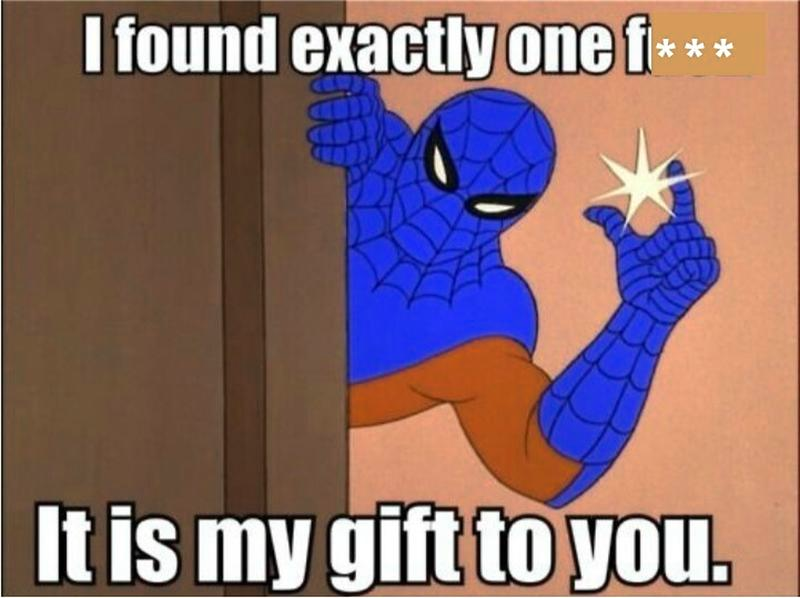

In [45]:
cv.imread(os.path.join(Kimages_path,image_files[0]))

Displaying: image_3003, Score: 1.0000


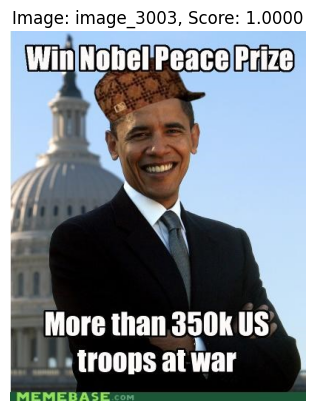

Displaying: image_3599, Score: 0.8897


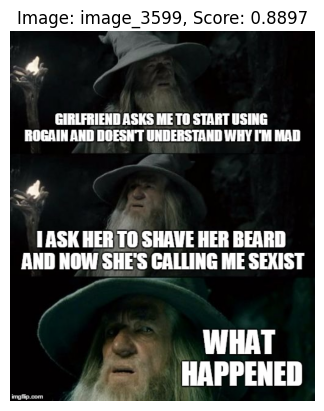

Displaying: image_827, Score: 0.8754


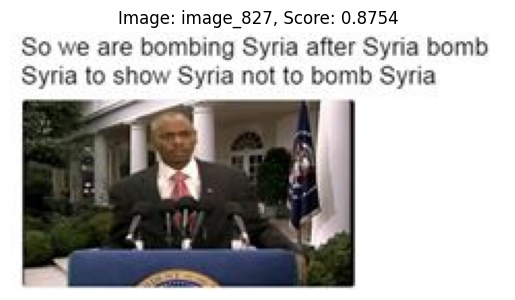

In [61]:
def display_images(recommendation):
    for image_name, score in recommendation:
        image_path = os.path.join(Kimages_path, image_name + '.jpg')
        image = cv.imread(image_path)

        print(f"Displaying: {image_name}, Score: {score:.4f}")

        if image is not None:
            plt.figure() # Prevents images from overwriting each other
            plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
            plt.title(f"Image: {image_name}, Score: {score:.4f}")
            plt.axis('off')
            plt.show()
        else:
            print(f"Warning: Could not load image at {image_path}")

result = recommend_similar_images(KimageVectors[5], KimageVectors, Klables)
display_images(result)